# Two-step Stress: a tutorial for the cognitive-load two-step task

## What is this package?

`two-step-stress` is a Python implementation of the Daw et al. (2011) two-step decision task, with a within-subject cognitive-load manipulation following Otto et al. (2013). It's aimed at psychology researchers who want to run the task on healthy volunteers and study how working-memory load shifts behaviour between model-based and model-free control. Right now the package ships the pure-logic engine — the probabilistic transitions, the drifting reward walks, and the 1-back letter task — all unit-tested and reproducible from a logged random seed. The PsychoPy display layer that turns this engine into a clickable experiment is in progress.

## Scenario

### Purpose

The package lets a researcher run a complete two-step task with a cognitive-load manipulation, collect clean per-participant CSV data, and compute the headline stay-probability analysis — without reimplementing the fiddly parts (probabilistic transitions, drifting reward walks, counterbalancing) from scratch each time.

### Who is this for

A psychology researcher — graduate student or postdoc — studying decision-making under cognitive load, who is comfortable with Python and wants a reproducible, scriptable version of the Daw two-step paradigm.

### Dependencies

- Python 3.10+
- `numpy`, `pandas`, `scipy`, `statsmodels`, `matplotlib`
- `psychopy` (for the display layer)
- Dev: `pytest`

Install from the repo root with `pip install -e .`, or `pip install -e ".[dev]"` to include the test dependencies.

### Scenario walkthrough

Day to day, you install the package, set your task parameters in `config.py` (trial counts, timing, transition probabilities, key mappings), and launch the experiment script once per participant. Each session writes one CSV to `data/` — one row per trial — plus a JSON sidecar recording the RNG seed and session metadata. Once data is collected, you run the analysis script to get the 2×2 stay-probability plot and the 1-back accuracy check. (The experiment and analysis scripts are still being built; the engine they sit on top of is what's shown below.)

## Task structure

In the two-step task, every trial starts with a **Stage-1** choice between two options (here, two spaceships). That choice leads *probabilistically* to one of two **Stage-2** states (two planets), where you make a second choice between two options (two aliens) and either get a reward (treasure) or don't. The twist is the transition structure: each Stage-1 choice has one planet it usually goes to — the **common** transition, which fires 70% of the time — and one it rarely goes to — the **rare** transition, the other 30%. These probabilities are fixed for the whole experiment.

The rewards, on the other hand, are not fixed. Each of the four Stage-2 options has its own reward probability that drifts slowly over trials via an independent Gaussian random walk (σ = 0.025), bouncing off reflecting boundaries at 0.25 and 0.75. So the best option keeps changing and a participant has to keep learning. The combination of *fixed transitions* and *drifting rewards* is exactly what lets us tell two strategies apart: a **model-based** one that uses knowledge of the transition structure to plan, versus a **model-free** one that just repeats whatever was rewarded last.

On top of this, the package adds a within-subject **cognitive-load manipulation** following Otto et al. (2013). In *load* blocks, a letter flashes at the start of each trial and the participant has to judge whether it matches the letter from the previous trial — a **1-back task** — pressing a key during the very window they're deliberating about their Stage-1 choice. This ties up working memory exactly when model-based planning would happen. *No-load* blocks are identical but without the letters. The experiment runs 200 trials split into 4 blocks of 50, with load and no-load blocks counterbalanced in **ABBA / BAAB** order across participants so block position can't be confounded with load.

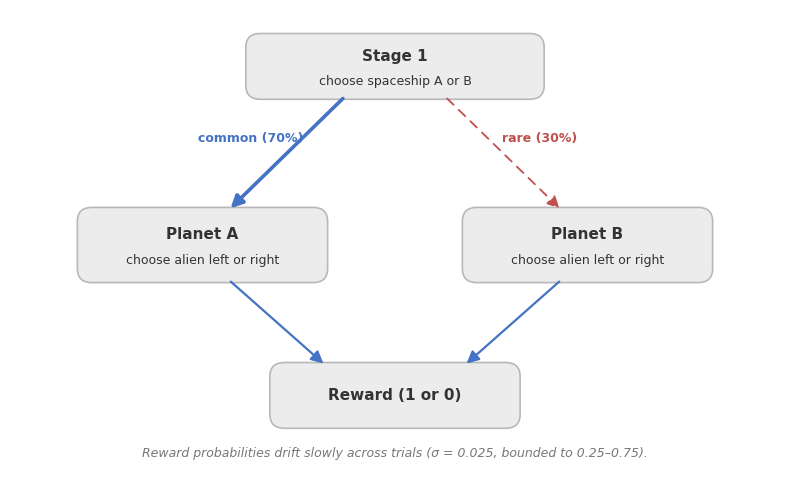

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Palette: soft greys for boxes; blue = common/reward, red = rare (matches the cell 18 plot).
BOX_FACE, BOX_EDGE, TEXT = "#ECECEC", "#B8B8B8", "#333333"
ACCENT, RARE = "#4472C4", "#C0504D"

fig, ax = plt.subplots(figsize=(8, 5))


def box(cx, cy, w, h, title, subtitle=None):
    """Rounded grey box centred at (cx, cy), with an optional subtitle line."""
    ax.add_patch(FancyBboxPatch(
        (cx - w / 2, cy - h / 2), w, h,
        boxstyle="round,pad=0.1,rounding_size=0.3",
        linewidth=1.2, edgecolor=BOX_EDGE, facecolor=BOX_FACE,
    ))
    if subtitle:
        ax.text(cx, cy + 0.22, title, ha="center", va="center", fontsize=11, weight="bold", color=TEXT)
        ax.text(cx, cy - 0.32, subtitle, ha="center", va="center", fontsize=9, color=TEXT)
    else:
        ax.text(cx, cy, title, ha="center", va="center", fontsize=11, weight="bold", color=TEXT)


def arrow(p0, p1, color, lw, dashed=False):
    ax.add_patch(FancyArrowPatch(
        p0, p1, arrowstyle="-|>", mutation_scale=18,
        linewidth=lw, color=color, shrinkA=4, shrinkB=4,
        linestyle=(0, (5, 4)) if dashed else "-",
    ))


# Nodes (canvas is 16 wide x 10 tall; figsize 8x5 keeps 1 unit square).
box(8, 8.8, 6.0, 1.2, "Stage 1", "choose spaceship A or B")
box(4, 5.0, 5.0, 1.4, "Planet A", "choose alien left or right")
box(12, 5.0, 5.0, 1.4, "Planet B", "choose alien left or right")
box(8, 1.8, 5.0, 1.2, "Reward (1 or 0)")

# Transition arrows: common emphasised (thick, solid), rare de-emphasised (thin, dashed).
arrow((7.0, 8.2), (4.5, 5.7), ACCENT, 2.6)
arrow((9.0, 8.2), (11.5, 5.7), RARE, 1.3, dashed=True)
ax.text(5.0, 7.2, "common (70%)", ha="center", fontsize=9, weight="bold", color=ACCENT)
ax.text(11.0, 7.2, "rare (30%)", ha="center", fontsize=9, weight="bold", color=RARE)

# Reward arrows (both Stage-2 states lead to the same reward outcome).
arrow((4.5, 4.3), (6.6, 2.4), ACCENT, 1.6)
arrow((11.5, 4.3), (9.4, 2.4), ACCENT, 1.6)

# Caption.
ax.text(8, 0.5, "Reward probabilities drift slowly across trials (σ = 0.025, bounded to 0.25–0.75).",
        ha="center", fontsize=9, style="italic", color="#777777")

ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
plt.axis("off")
plt.tight_layout()
plt.show()


## The building blocks

This section walks through the six public functions the package exposes, each with a small runnable example. Together they are the engine the live experiment is built on: the transition logic, the drifting reward walks, and the 1-back letter task. Every function takes an explicit `numpy` random generator, so each example below is fully reproducible.

### `build_transition_mapping`

Sets up which Stage-1 choice commonly leads to which Stage-2 state for a given participant. There are only two possible mappings, and which one a participant gets is decided by their counterbalance ID being even or odd — this keeps the common/rare structure balanced across your sample. The returned dict says, for each Stage-1 action, which Stage-2 state is its *common* destination.

In [2]:
from two_step_stress import build_transition_mapping

print(build_transition_mapping(0))  # even counterbalance ID
print(build_transition_mapping(1))  # odd counterbalance ID

{0: 0, 1: 1}
{0: 1, 1: 0}


### `apply_transition`

Takes a Stage-1 choice and rolls the dice on where the participant ends up. With probability 0.7 they land in the common Stage-2 state for that choice; with probability 0.3 they're bumped to the rare one. It returns both the resulting state and whether the transition was `'common'` or `'rare'` — exactly the information the stay-probability analysis needs later.

In [3]:
import numpy as np
from two_step_stress import apply_transition, build_transition_mapping

rng = np.random.default_rng(0)
mapping = build_transition_mapping(0)
# Take Stage-1 action 0 five times and see where it lands.
print([apply_transition(0, mapping, rng) for _ in range(5)])

[(0, 'common'), (0, 'common'), (0, 'common'), (0, 'common'), (1, 'rare')]


### `initialise_reward_probs`

Sets the starting reward probabilities for the four Stage-2 options. Each is drawn independently and uniformly between 0.25 and 0.75, so no option starts off obviously best. You call this once at the start of a participant's session.

In [4]:
import numpy as np
from two_step_stress import initialise_reward_probs

rng = np.random.default_rng(0)
print(initialise_reward_probs(rng).round(3))

[0.568 0.385 0.27  0.258]


### `step_reward_probs`

Advances those four probabilities by one trial's worth of drift. Each one takes a small Gaussian step (σ = 0.025) and reflects off the boundaries at 0.25 and 0.75 so it never escapes the valid range. Calling this once per trial is what makes the reward landscape slowly shift, forcing participants to keep learning.

In [5]:
import numpy as np
from two_step_stress import initialise_reward_probs, step_reward_probs

rng = np.random.default_rng(0)
probs = initialise_reward_probs(rng)
for _ in range(3):  # walk forward three trials
    probs = step_reward_probs(probs, rng)
    print(probs.round(3))

[0.555 0.394 0.303 0.282]
[0.537 0.362 0.288 0.283]
[0.479 0.357 0.256 0.265]


### `generate_letter_stream`

Builds the sequence of letters for the 1-back task in a load block. It returns the letters plus a parallel list flagging which ones are matches to the previous letter, hitting a target match rate you specify (the package default is about 33%). The first letter is never a match — there's nothing before it.

In [6]:
import numpy as np
from two_step_stress import generate_letter_stream

rng = np.random.default_rng(0)
letters, is_match = generate_letter_stream(8, 0.33, rng)
print(letters)
print(is_match)

['W', 'W', 'W', 'W', 'P', 'M', 'R', 'N']
[False, True, True, True, False, False, False, False]


### `score_nback_response`

Grades a participant's 1-back keypress. Given whether the current letter really was a match and which key they pressed, it returns whether they were correct and the signal-detection label for the response — `'hit'`, `'miss'`, `'false_alarm'`, or `'correct_rejection'`. Those labels feed straight into the 1-back accuracy manipulation check.

In [7]:
from two_step_stress import score_nback_response

# Letter was a match and they pressed the match key 'z' -> a hit.
print(score_nback_response(True, "z", key_match="z", key_no_match="m"))
# Letter was not a match but they pressed 'z' anyway -> a false alarm.
print(score_nback_response(False, "z", key_match="z", key_no_match="m"))

(True, 'hit')
(False, 'false_alarm')


## Example application: MB vs MF agents

To convince ourselves the engine actually behaves like the two-step task should, we can simulate agents playing it and check the result against a known prediction from Daw et al. (2011, Figure 2). The key measure is **stay probability**: the chance a participant repeats their previous Stage-1 choice, broken down by whether the last trial was rewarded and whether the last transition was common or rare.

The two textbook patterns are:

- A **model-free** agent only cares whether the last choice was rewarded. Its stay probability depends on reward alone — the common/rare distinction makes no difference, so the bars come out flat within each reward condition.
- A **model-based** agent uses the transition structure. After a *rare* transition it knows the reward really belongs to the *other* Stage-1 choice, so reward and transition interact — producing a crossover: stay is high after rewarded-common and unrewarded-rare, low after rewarded-rare and unrewarded-common.

Below we run both agents through 5,000 trials of the real `apply_transition` / `step_reward_probs` engine and plot the result.

> **Note:** the MF agent in this notebook uses a simplified update rule (`q1[a1] += α·(r − q1[a1])`) for pedagogical clarity. The more formally-correct SARSA(λ=0) update used in `scripts/sanity_check.py` is `q1[a1] += α·(r − q2[s2,a2])`; both produce the same qualitative MF signature (flat across common/rare within each reward condition).

MF: rewarded(common=0.82, rare=0.78)  unrewarded(common=0.52, rare=0.54)
MB: rewarded(common=0.60, rare=0.45)  unrewarded(common=0.47, rare=0.60)


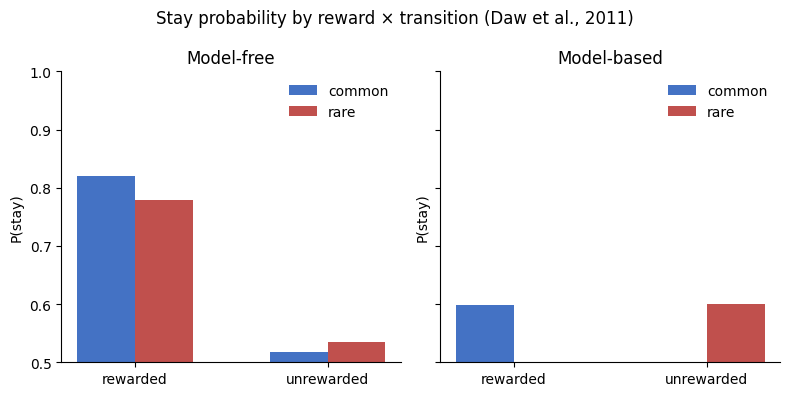

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from two_step_stress import (
    build_transition_mapping,
    apply_transition,
    initialise_reward_probs,
    step_reward_probs,
)
from two_step_stress.config import P_COMMON, P_RARE

N_TRIALS = 5_000
ALPHA = 0.3   # learning rate
BETA = 5.0    # softmax inverse temperature
SEED = 42


def softmax_choice(q, rng):
    """Pick an action from a softmax over action values q."""
    e = np.exp(BETA * (q - q.max()))
    return int(rng.choice(len(q), p=e / e.sum()))


def simulate(mode, rng):
    """Run one agent ('mf' or 'mb') through the task; return (choice, reward, transition) per trial."""
    mapping = build_transition_mapping(0)
    reward_probs = initialise_reward_probs(rng)
    q2 = np.full((2, 2), 0.5)  # Stage-2 values [state, action]
    q1 = np.full(2, 0.5)       # Stage-1 values (MF updates these; MB recomputes them)

    records = []
    for _ in range(N_TRIALS):
        # Model-based agent re-derives Stage-1 values from Stage-2 values each trial,
        # weighting by the known 70/30 transition structure.
        if mode == "mb":
            q1 = np.array([
                P_COMMON * q2[mapping[a]].max() + P_RARE * q2[1 - mapping[a]].max()
                for a in range(2)
            ])
        a1 = softmax_choice(q1, rng)

        s2, transition = apply_transition(a1, mapping, rng)
        a2 = softmax_choice(q2[s2], rng)
        reward = int(rng.random() < reward_probs[s2 * 2 + a2])

        # Learn: update the chosen Stage-2 value; MF also updates Stage-1 from reward directly.
        q2[s2, a2] += ALPHA * (reward - q2[s2, a2])
        if mode == "mf":
            q1[a1] += ALPHA * (reward - q1[a1])

        reward_probs = step_reward_probs(reward_probs, rng)
        records.append((a1, reward, transition))
    return records


def stay_matrix(records):
    """P(repeat Stage-1 choice) split by previous reward (0/1) x transition (common/rare)."""
    counts = {r: {t: [0, 0] for t in ("common", "rare")} for r in (0, 1)}
    for i in range(1, len(records)):
        prev_a1, prev_r, prev_t = records[i - 1]
        counts[prev_r][prev_t][0] += int(records[i][0] == prev_a1)
        counts[prev_r][prev_t][1] += 1
    return {r: {t: counts[r][t][0] / counts[r][t][1] for t in ("common", "rare")} for r in (0, 1)}


def plot_panel(ax, mat, title):
    x, w = np.array([0.0, 1.0]), 0.3
    ax.bar(x - w / 2, [mat[1]["common"], mat[0]["common"]], w, label="common", color="#4472C4")
    ax.bar(x + w / 2, [mat[1]["rare"], mat[0]["rare"]], w, label="rare", color="#C0504D")
    ax.set_xticks(x)
    ax.set_xticklabels(["rewarded", "unrewarded"])
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel("P(stay)")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)


mf = stay_matrix(simulate("mf", np.random.default_rng(SEED)))
mb = stay_matrix(simulate("mb", np.random.default_rng(SEED + 1)))

for name, mat in [("MF", mf), ("MB", mb)]:
    print(f"{name}: rewarded(common={mat[1]['common']:.2f}, rare={mat[1]['rare']:.2f})  "
          f"unrewarded(common={mat[0]['common']:.2f}, rare={mat[0]['rare']:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
plot_panel(axes[0], mf, "Model-free")
plot_panel(axes[1], mb, "Model-based")
fig.suptitle("Stay probability by reward × transition (Daw et al., 2011)")
fig.tight_layout()
plt.show()

The two panels show exactly the predicted split. The **model-free** agent's bars are essentially flat within each reward condition — common and rare sit at the same height, so only *whether* the last trial paid off matters. The **model-based** agent shows the crossover: stay probability is high after rewarded-common and unrewarded-rare trials, and low after rewarded-rare and unrewarded-common ones, because it reasons through the transition structure instead of just repeating what worked. Getting both patterns out of the same `apply_transition` / `step_reward_probs` code the live task uses is good evidence the engine is behaving correctly.

## What's next

Next up is the PsychoPy display layer — the instruction screens, the trial loop that puts spaceships and planets on screen, and the data logging that writes one CSV per participant. After that comes the analysis pipeline: the 2×2 stay-probability plot comparing load against no-load blocks, plus the 1-back accuracy manipulation check to confirm the load task actually taxed working memory. The target is a working end-to-end experiment by May 29.